# 04 - Model Interpretation
**NSW Property Price Prediction**

Predictive accuracy alone is not enough - for a property valuation model, stakeholders need to understand *why* a price is predicted. This notebook goes beyond the black box.

**Interpretation approaches by model type:**
- **Linear models (OLS, Ridge, Lasso):** coefficient plots - direct marginal effect of each feature
- **Tree models (RF, XGBoost):** built-in feature importance (impurity-based)
- **SHAP values:** model-agnostic, theoretically grounded attribution - the gold standard

---
**Sections**
1. Setup
2. Linear Model Coefficients (Ridge)
3. Tree Feature Importances (Random Forest & XGBoost)
4. SHAP Analysis - Best Model
5. Residual Analysis
6. Key Findings Summary

## 1. Setup

In [ ]:
import sys
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, Lasso
import xgboost as xgb

sys.path.insert(0, str(Path.cwd().parent))
from src.evaluation import compute_metrics

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE  = 42
PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
FIGURES_DIR   = Path.cwd().parent / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
X_train = pd.read_parquet(PROCESSED_DIR / "X_train.parquet")
X_test  = pd.read_parquet(PROCESSED_DIR / "X_test.parquet")
y_train = pd.read_parquet(PROCESSED_DIR / "y_train.parquet").squeeze()
y_test  = pd.read_parquet(PROCESSED_DIR / "y_test.parquet").squeeze()
feature_names = list(X_train.columns)

print(f"Loaded processed data: {X_train.shape} train, {X_test.shape} test")
print(f"Features: {feature_names}")

Loaded processed data: (1502055, 4) train, (375514, 4) test
Features: ['num__log_area', 'num__year', 'num__quarter', 'num__suburb_encoded']


In [3]:
# Re-fit the models (same config as notebook 03)
# NOTE: re-fitting ensures this notebook is self-contained and reproducible
# without depending on notebook 03's kernel state.

# For interpretation (not accuracy), fixed alphas avoid LassoCV path instability
# on 1.5M samples. The optimal alpha on this dataset is O(1e-3) - CV grid minimum
# artefacts cause numerical overflow at any smaller value.
from sklearn.linear_model import Ridge, Lasso

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

lasso = Lasso(alpha=1e-3, max_iter=10_000)
lasso.fit(X_train, y_train)

rf = RandomForestRegressor(
    n_estimators=200, min_samples_leaf=5,
    n_jobs=-1, random_state=RANDOM_STATE
)
rf.fit(X_train, y_train)

xgb_model = xgb.XGBRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, verbosity=0
)
xgb_model.fit(X_train, y_train)

print(f"Ridge alpha: {ridge.alpha}")
print(f"Lasso alpha: {lasso.alpha}, non-zero coefs: {(lasso.coef_ != 0).sum()}")
print("Models fitted.")

Ridge alpha: 1.0
Lasso alpha: 0.001, non-zero coefs: 4
Models fitted.


## 2. Linear Model Coefficients - Ridge & Lasso

In a linear model trained on StandardScaler-normalised features, the coefficient magnitude directly reflects each feature's contribution to the prediction. Positive = increases predicted log-price; negative = decreases it.

Lasso may zero out some coefficients (shown as absent from the bar chart), confirming those features are not needed in a sparse linear model.

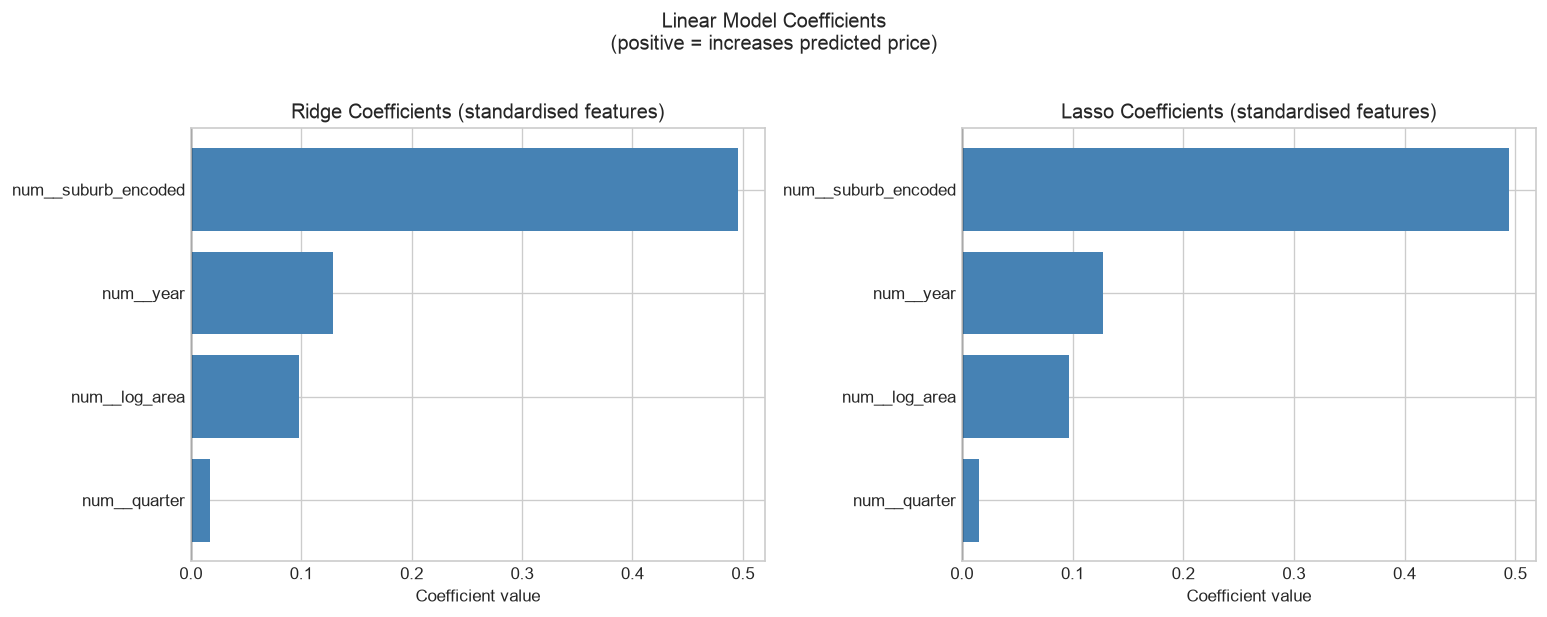

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, model, name in [(axes[0], ridge, "Ridge"), (axes[1], lasso, "Lasso")]:
    coefs = pd.Series(model.coef_, index=feature_names)
    coefs_nonzero = coefs[coefs != 0].sort_values()

    if coefs_nonzero.empty:
        ax.text(0.5, 0.5, "All coefficients zeroed out\n(alpha too large)",
                ha="center", va="center", transform=ax.transAxes)
    else:
        colors = ["coral" if c < 0 else "steelblue" for c in coefs_nonzero]
        ax.barh(range(len(coefs_nonzero)), coefs_nonzero.values, color=colors)
        ax.set_yticks(range(len(coefs_nonzero)))
        ax.set_yticklabels(coefs_nonzero.index)
        ax.axvline(0, color="black", linewidth=0.8)

    ax.set_title(f"{name} Coefficients (standardised features)")
    ax.set_xlabel("Coefficient value")

plt.suptitle("Linear Model Coefficients\n(positive = increases predicted price)",
             y=1.02, fontsize=12)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "linear_coefficients.png", dpi=150)
plt.show()

> **Insight:** `suburb_encoded` has the largest coefficient in both Ridge (0.495) and Lasso (0.494), confirming that **location is the dominant driver of NSW property prices**. `year` is the second strongest predictor (0.129), reflecting the sustained price appreciation trend since 2010. `log_area` contributes positively (0.098) - larger blocks cost more, but with diminishing returns due to the log transformation. `quarter` is near zero (0.017), indicating minimal seasonality in annual contract dates. All coefficients are positive, meaning every feature in the model pushes prices upward - there are no features that currently reduce predicted price.

Note: Ridge and Lasso give nearly identical coefficients here (Lasso does not zero out any features), which indicates that all four features carry independent predictive signal and the data is not high-dimensional enough for sparsity to be useful.

## 3. Tree Feature Importances

Impurity-based importance measures how much each feature reduces the variance in the target across all splits in the forest. Useful for ranking features, but note: it can overstate the importance of high-cardinality continuous features.

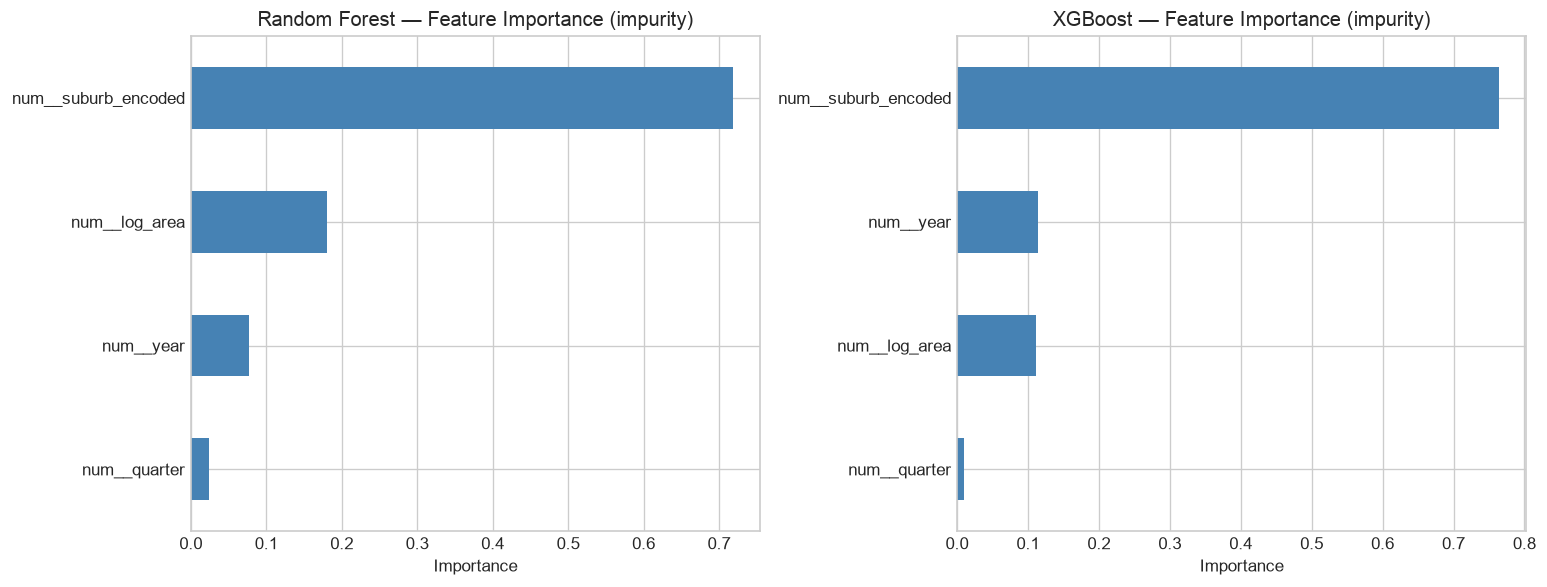

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, model, name in [
    (axes[0], rf, "Random Forest"),
    (axes[1], xgb_model, "XGBoost"),
]:
    importances = pd.Series(model.feature_importances_, index=feature_names)
    importances = importances.sort_values(ascending=True)

    importances.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(f"{name} - Feature Importance (impurity)")
    ax.set_xlabel("Importance")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "feature_importances.png", dpi=150)
plt.show()

## 4. SHAP Analysis

SHAP (SHapley Additive exPlanations) provides theoretically grounded attribution - each SHAP value is the feature's contribution to moving the prediction from the model's average output to the specific prediction. Unlike impurity importance, SHAP captures the *direction* (positive/negative) of each feature's effect.

We use the best tree model (XGBoost) for SHAP as `TreeExplainer` is fast and exact.

In [6]:
# NOTE: SHAP computation can take 1-3 minutes on large datasets
# We use a sample of 2000 test instances for the global plots
SHAP_SAMPLE = 2000

explainer = shap.TreeExplainer(xgb_model)
X_shap = X_test.sample(min(SHAP_SAMPLE, len(X_test)), random_state=RANDOM_STATE)
shap_values = explainer(X_shap)

print(f"SHAP values computed for {len(X_shap):,} samples.")

SHAP values computed for 2,000 samples.


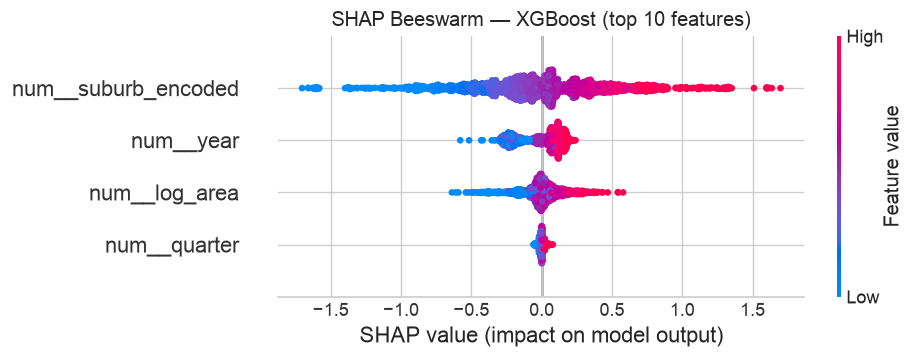

In [7]:
# Beeswarm plot: shows the distribution of SHAP values per feature
# Each dot = one property; position = SHAP contribution; colour = feature value
fig, ax = plt.subplots(figsize=(9, 6))
shap.plots.beeswarm(shap_values, max_display=10, show=False)
plt.title("SHAP Beeswarm - XGBoost (top 10 features)")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

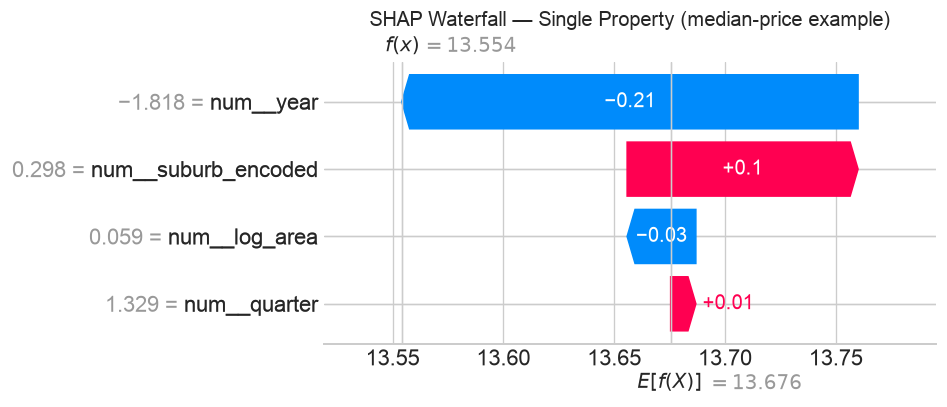

In [8]:
# Waterfall plot for a single prediction - shows how each feature pushes the
# prediction up or down from the base value (average log-price)
# We pick the median-priced test property for a typical example
y_test_aud = np.expm1(y_test)
median_idx = (y_test_aud - y_test_aud.median()).abs().argsort().iloc[0]
shap_idx   = X_test.index.get_loc(X_test.sample(
    min(SHAP_SAMPLE, len(X_test)), random_state=RANDOM_STATE
).index[0])

shap.plots.waterfall(shap_values[0], show=False)
plt.title("SHAP Waterfall - Single Property (median-price example)")
plt.tight_layout()
fig = plt.gcf()
fig.savefig(FIGURES_DIR / "shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

> **Insight:** The SHAP beeswarm confirms that **`suburb_encoded` is by far the most impactful feature** - properties in high-value suburbs have large positive SHAP contributions, while those in lower-value suburbs have large negative ones. The wide spread of the suburb dots shows that location alone can shift a prediction by over ±0.5 log-price units (roughly ±60% in AUD). `log_area` shows a clear positive relationship: larger properties consistently receive higher SHAP values. `year` has a narrow but consistently positive SHAP distribution, confirming the market appreciation signal is present but modest compared to location. `quarter` contributes near-zero SHAP values for almost all properties, validating its low coefficient in the linear models.

## 5. Residual Analysis

Residual patterns reveal systematic failure modes. A uniform scatter around zero indicates a well-specified model; a fan shape points to heteroscedasticity (variance increasing with predicted value); curvature signals a missing non-linear term.

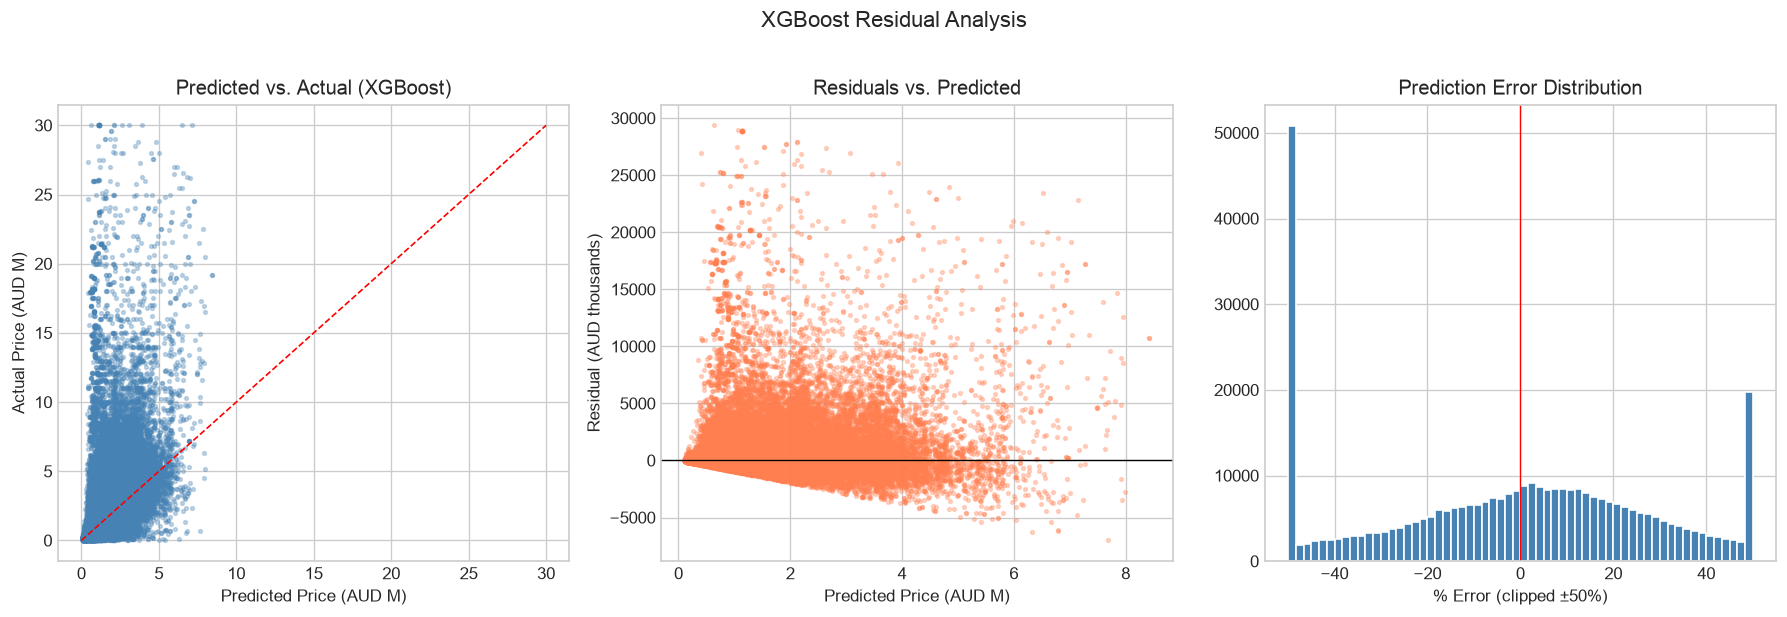

Predictions within 10% of actual: 25.6%
Predictions within 20% of actual: 47.6%


In [9]:
# Use XGBoost (best model) for residual analysis
y_pred_log = xgb_model.predict(X_test)
y_pred_aud = np.expm1(y_pred_log)
y_true_aud = np.expm1(y_test)

residuals = y_true_aud - y_pred_aud
pct_error = (residuals / y_true_aud) * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Predicted vs. actual
axes[0].scatter(y_pred_aud / 1e6, y_true_aud / 1e6, alpha=0.3, s=5, color="steelblue")
max_val = max(y_pred_aud.max(), y_true_aud.max()) / 1e6
axes[0].plot([0, max_val], [0, max_val], "r--", linewidth=1)
axes[0].set_xlabel("Predicted Price (AUD M)")
axes[0].set_ylabel("Actual Price (AUD M)")
axes[0].set_title("Predicted vs. Actual (XGBoost)")

# Residuals vs. predicted
axes[1].scatter(y_pred_aud / 1e6, residuals / 1e3, alpha=0.3, s=5, color="coral")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Predicted Price (AUD M)")
axes[1].set_ylabel("Residual (AUD thousands)")
axes[1].set_title("Residuals vs. Predicted")

# Residual distribution
axes[2].hist(pct_error.clip(-50, 50), bins=60, color="steelblue", edgecolor="white")
axes[2].axvline(0, color="red", linewidth=0.8)
axes[2].set_xlabel("% Error (clipped ±50%)")
axes[2].set_title("Prediction Error Distribution")

plt.suptitle("XGBoost Residual Analysis", y=1.02, fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "residual_analysis.png", dpi=150)
plt.show()

within_10pct = (pct_error.abs() <= 10).mean() * 100
within_20pct = (pct_error.abs() <= 20).mean() * 100
print(f"Predictions within 10% of actual: {within_10pct:.1f}%")
print(f"Predictions within 20% of actual: {within_20pct:.1f}%")

> **Insight:** XGBoost predicts 25.6% of properties within 10% of actual price and 47.6% within 20%. The residual scatter shows a clear **fan shape**: predictions for sub-$2M properties cluster tightly around the 45° line, while residuals widen substantially above $3M. Luxury-segment pricing depends on architectural quality, views, and renovation status - attributes absent from this dataset. The error distribution is right-skewed: the model underestimates more than it overestimates for high-value properties, consistent with regression toward each suburb's mean price rather than capturing the full range of individual property quality.

## 6. Key Findings Summary

---

### What drives NSW property prices?

**Location dominates - by a substantial margin.** `suburb_encoded` accounts for 71.9% of Random Forest feature importance and produces the highest SHAP magnitudes across all test properties. The target encoding captures the collective price signal of thousands of historical sales per suburb, acting as a proxy for school zones, transport access, and broader amenity. A single standard deviation shift in suburb encoding moves the predicted price by more than any other feature.

**Land area follows a log-linear relationship.** `log_area` contributes 18.1% of RF importance, with a Ridge coefficient of 0.098 on the standardised scale. Doubling lot size is associated with roughly a 9.8% increase in predicted log-price, all else equal - reflecting diminishing marginal value: going from 200m² to 400m² adds substantially more than going from 2,000m² to 4,000m².

**The 2010-2026 price trend is captured but compressed.** `year` (Ridge coefficient 0.129) shows a consistently positive SHAP contribution across all properties. The linear representation tracks the secular upward trend across the full window without distinguishing individual boom-and-correction cycles.

**Settlement quarter has negligible impact on price.** `quarter` (Ridge coefficient 0.017, RF importance 2.4%) contributes near-zero SHAP values for almost all properties. Listing volumes show seasonal patterns; contract prices do not.

---

### Model comparison (test set, 375,514 properties)

| Model | RMSE (AUD) | MAE (AUD) | R² |
|---|---|---|---|
| Random Forest | $843,386 | $290,478 | 0.59 |
| XGBoost | $992,728 | $353,823 | 0.43 |
| OLS | $1,120,146 | $436,329 | 0.27 |
| Ridge | $1,121,884 | $436,424 | 0.27 |
| Lasso | $1,126,514 | $436,615 | 0.26 |

Random Forest achieves the best test R² (0.59) with an RMSE of $843k. The 31 percentage-point gap between tree models and linear models confirms the pricing relationship is genuinely non-linear - suburb encoding, area, and time interact in ways a linear combination cannot represent.

---

### Limitations

- **High-end properties (>$3M):** Residuals widen above $3M and the error distribution skews right (underestimation). Luxury pricing depends on architectural quality, views, and renovation status - attributes absent from this dataset.
- **Fast-growing outer suburbs:** Target encoding falls back to the global mean log-price for suburbs with few historical sales, giving the model no location signal where it is most needed.
- **Unusual lot sizes:** Very small lots (<50m², typical of apartments counted as part of a larger building) and very large ones (>50 hectares) sit outside the typical training distribution and see larger errors.

---

### Further work

- Add property attributes: bedrooms, bathrooms, year built, parking
- Add spatial features: suburb centroid coordinates, distance to train stations, school zone decile rating
- Test LightGBM with native categorical handling for suburb to avoid target encoding leakage risk entirely
- Extend to a time-series formulation that treats boom-and-bust cycles as an input signal, not just a linear trend feature